In [1]:
from pathlib import Path
import torch
import seaborn as sns
sns.set_context("talk")
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    REPO = Path("/content/motionnet_cnn")
    if REPO.exists():
        !cd {REPO} && git pull
    else:
        !git clone https://github.com/guardomayas/motionnet.git {REPO}
    !pip install -q -e {REPO}
    import site, importlib
    site.main(); importlib.invalidate_caches()

from motionnet.paths import setup, compose
from motionnet.dataset.prepare import prepare_data
from torch.utils.data import DataLoader
import seaborn as sns

sns.set_context("talk")
P = setup(IN_COLAB)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg, _ = compose(exp_name="s01_lambda2", data="eye31_150fps", model="base", corpus=P.corpus)
train_mem, val_mem, info = prepare_data(cfg, device, P.coeffs, P.movies)
print(P.corpus, len(list(P.corpus.glob("*.iml"))), "images")

/home/guardomayas/NUIN/motionnet/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/guardomayas/NUIN/motionnet/src/motionnet/dataset/prepare.py:43: RuntimeWarning: excursion budget is tight on x: limit 515 px is 2.3 sigma of the position spread (229 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 200), or start_jitter (now 40).
  base = GetNaturalMovies(files=files, coeff_cache=coeff, seed=seed, **mcfg)
/home/guardomayas/NUIN/motionnet/src/motionnet/dataset/prepare.py:43: RuntimeWarning: excursion budget is tight on y: limit 259 px is 1.9 sigma of the position spread (134 px). In 'reject' mode this means many redraws. Reduce vel_std_deg_s (now (120.0, 70.0)), frames_per_segment (now 200), or start_jitter (now 40).
  base = GetNatu

/home/guardomayas/NUIN/van_hateren/vanhateren_iml 4167 images


In [2]:
P.ckpt

PosixPath('/home/guardomayas/NUIN/motionnet/data/ckpt')

In [3]:
import torch
from motionnet.paths import setup, compose
from motionnet.dataset.prepare import prepare_data
from motionnet.train import load_checkpoint, compute_v_std
# from motionnet.analysis import layer2_tuning, dsi_summary
from torch.utils.data import DataLoader

P = setup(IN_COLAB)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cfg, _ = compose(exp_name="s01_lambda2", data="eye31_150fps", model="base",
                 corpus=P.corpus)
train_mem, val_mem, info = prepare_data(cfg, device, P.coeffs, P.movies)
val_dl = DataLoader(val_mem, batch_size=cfg["optim"]["batch_size"], num_workers=0)

model, ck = load_checkpoint(P.ckpt / "adhoc.pt", device, info)
history = ck["history"]
L = ck["cfg"]["loss"]
V_STD = ck["v_std"].to(device)              # from the checkpoint, not recomputed
VALID = slice(ck["valid_start"], None)
GRAY  = ck["gray_frames"]

materializing: 100%|██████████| 120/120 [00:00<00:00, 1629.33it/s]

support: 32 frames = 207 ms
rank: 8 of 8
condition number: 16.411417535364563


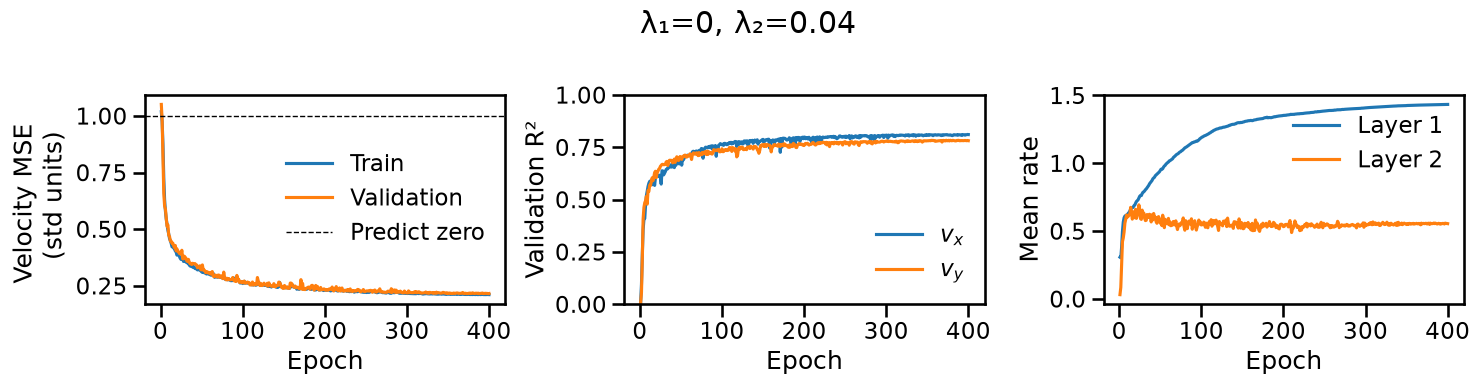

In [4]:
### Training summary
import pandas as pd
import matplotlib.pyplot as plt
epochs = range(1, len(history["train"]) + 1)


tr = pd.DataFrame(history["train"])
va = pd.DataFrame(history["val"])
epochs = range(1, len(tr) + 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(epochs, tr["mse"], label="Train")
ax[0].plot(epochs, va["mse"], label="Validation")
ax[0].axhline(1.0, ls="--", lw=1, c="k", label="Predict zero")
ax[0].set(xlabel="Epoch", ylabel="Velocity MSE \n (std units)")

ax[1].plot(epochs, va["r2_x"], label="$v_x$")
ax[1].plot(epochs, va["r2_y"], label="$v_y$")
ax[1].set(xlabel="Epoch", ylabel="Validation R²", ylim=(0, 1))

ax[2].plot(epochs, va["rate1"], label="Layer 1")
ax[2].plot(epochs, va["rate2"], label="Layer 2")
ax[2].set(xlabel="Epoch", ylabel="Mean rate")

for a in ax:
    a.legend(frameon=False)
fig.suptitle(f"λ₁={L['lambda_1']:g}, λ₂={L['lambda_2']:g}")
fig.tight_layout()
plt.show()

In [5]:
from motionnet.analysis import plot_cnn_subunits_1, plot_cnn_subunits_2

Plotting 10 subunits


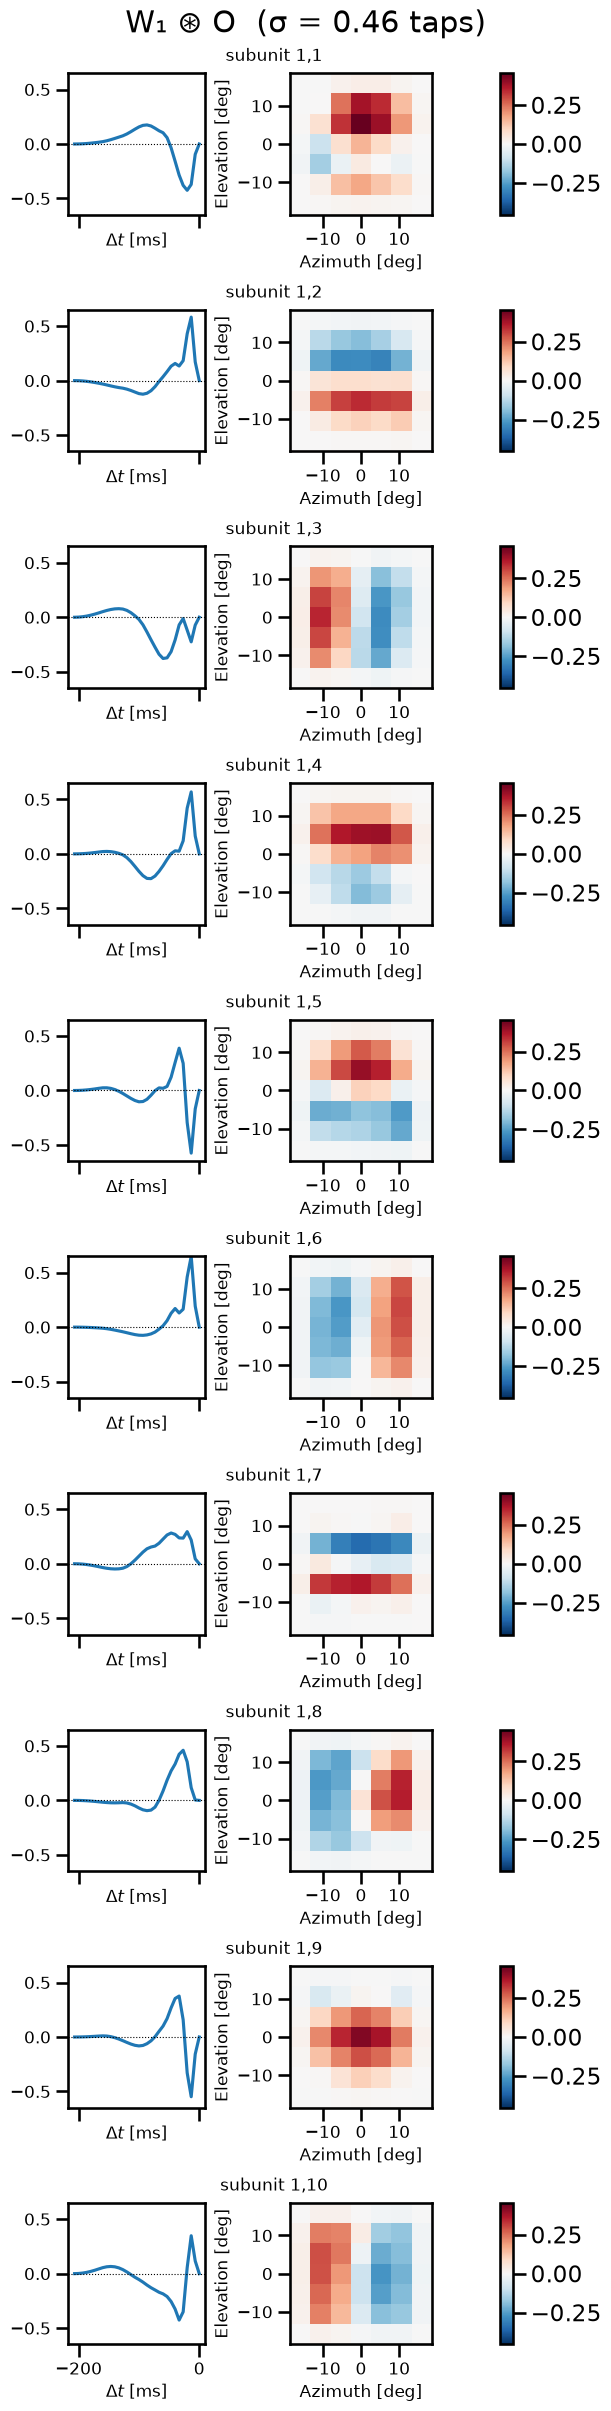

In [6]:
_, _ = plot_cnn_subunits_1(model, info, effective=True)

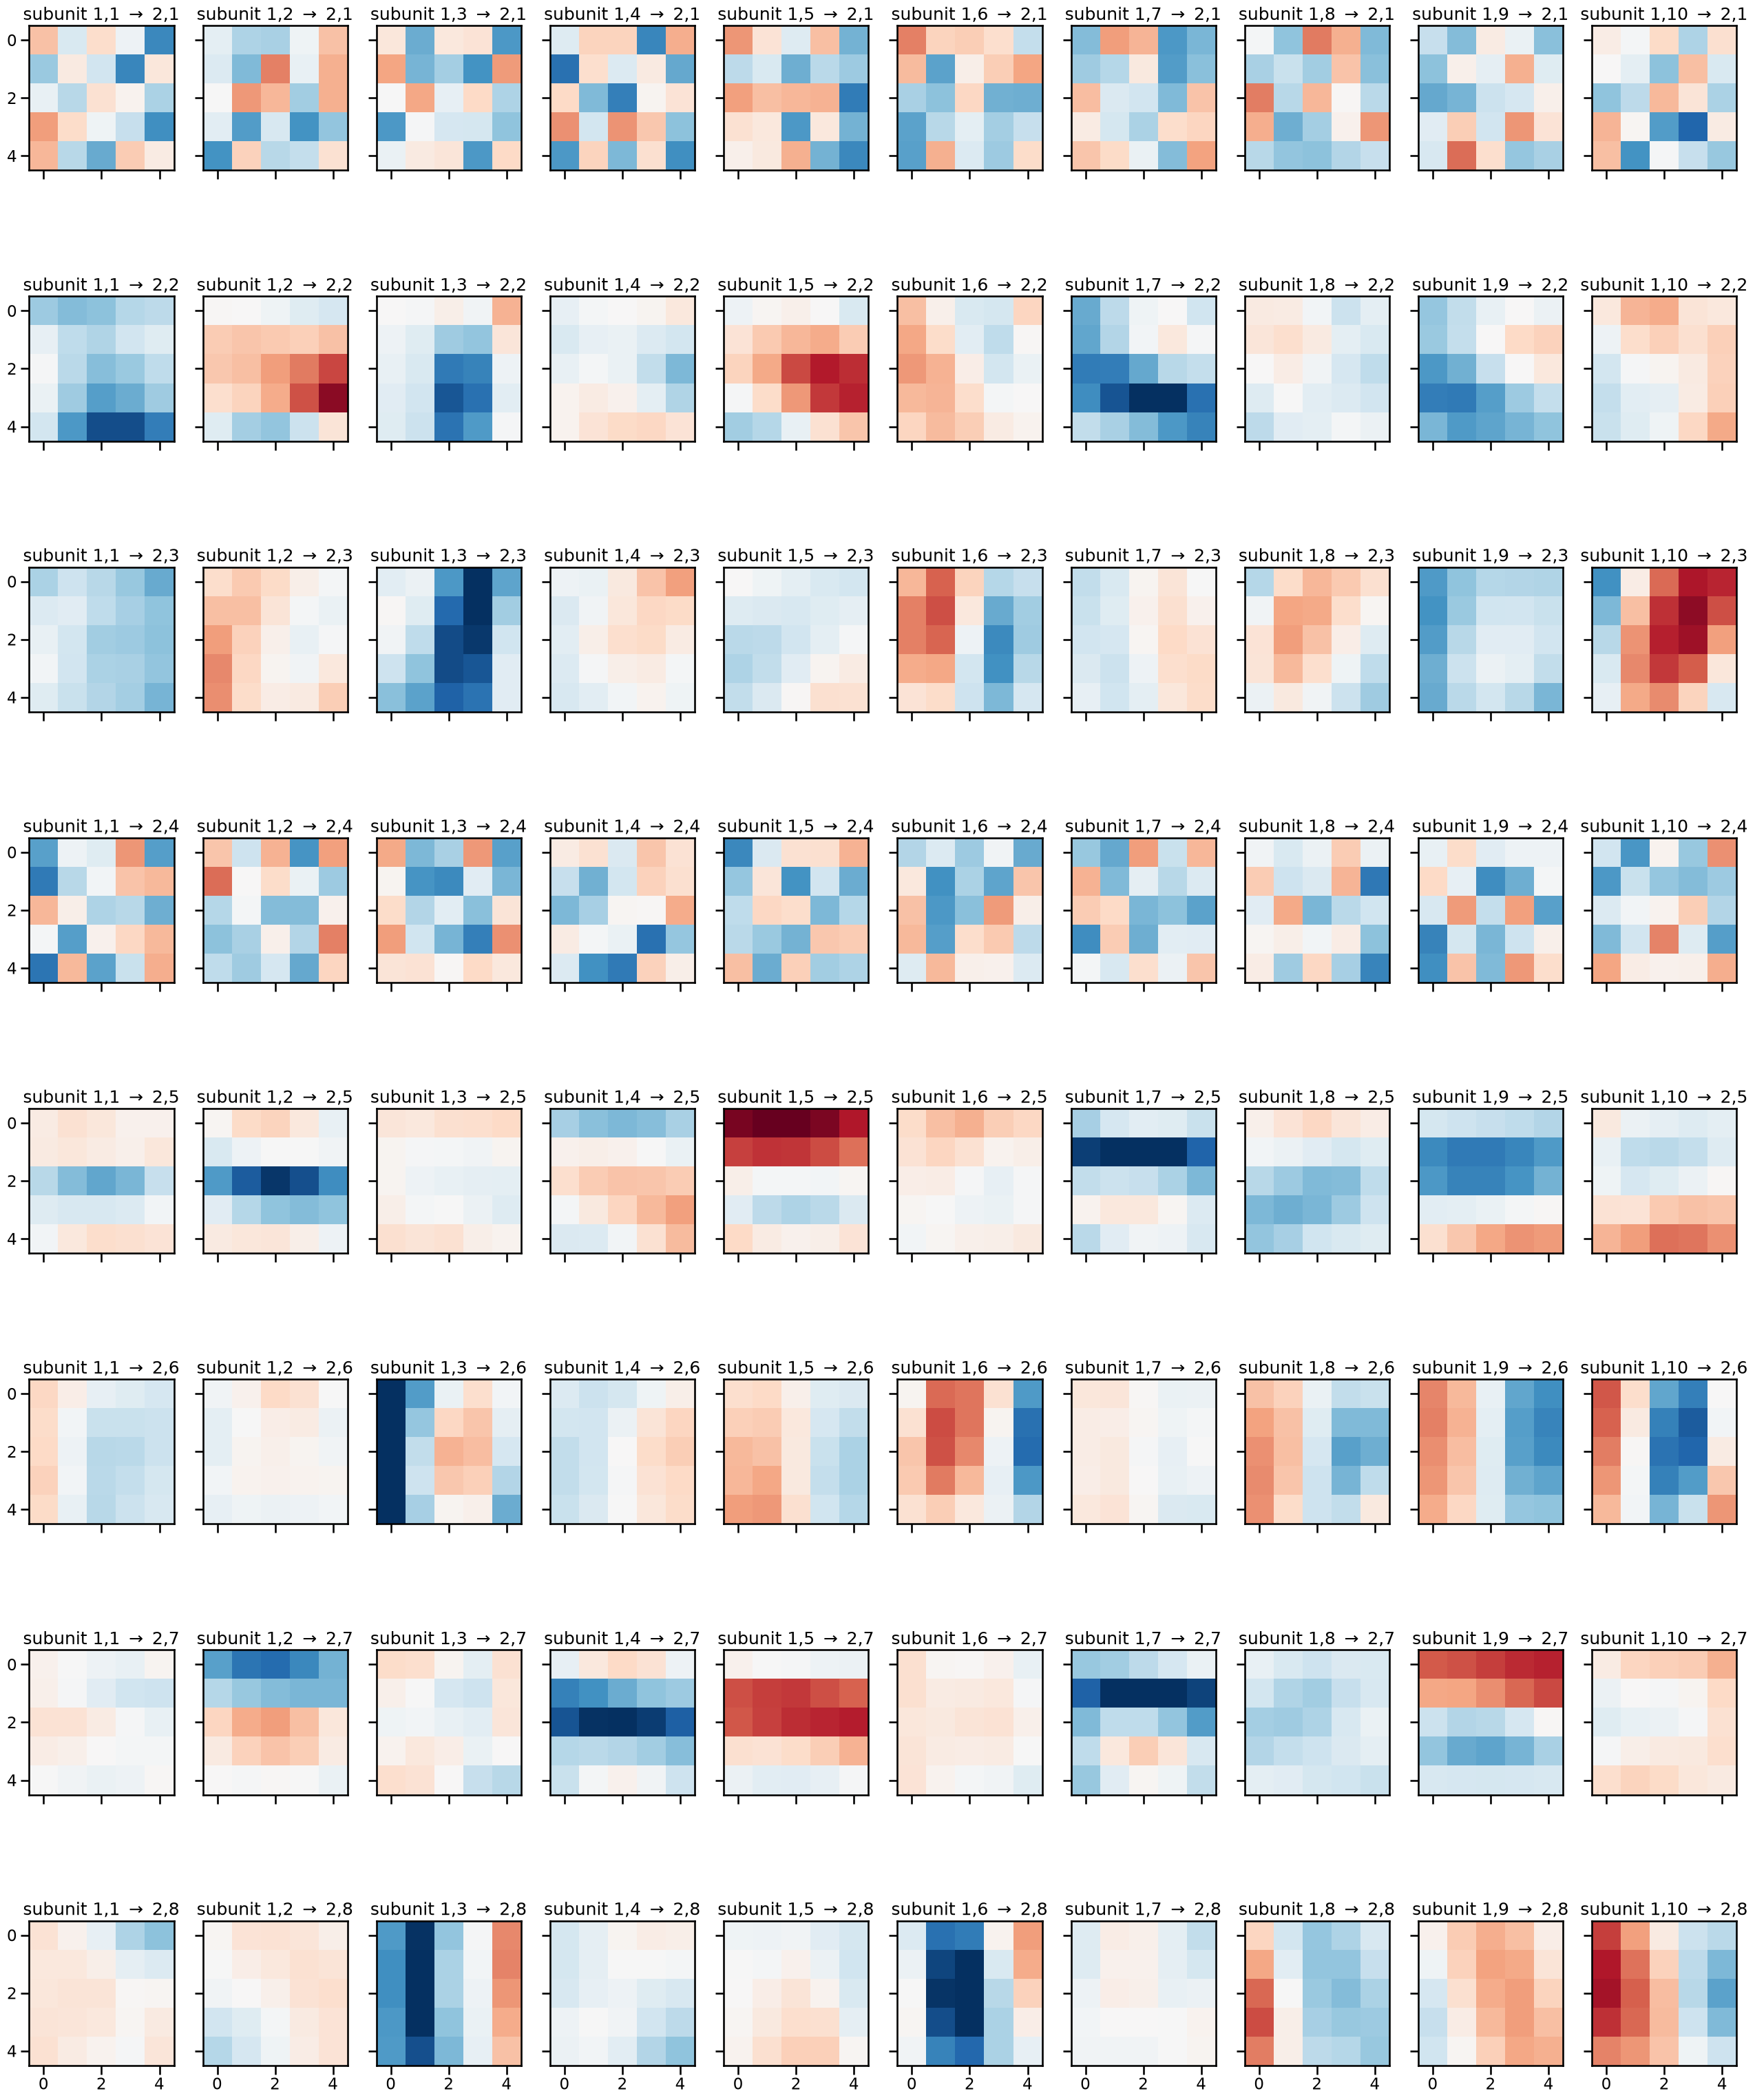

In [7]:
plot_cnn_subunits_2(model)

## Tuning curves for layer two neurons

For each batch movie $b$ and time step $t \in \mathcal{V}$, define a sample $s = (b,t)$ and take
- $ \mathbf{r}_s \in \mathbb{R}^{N_2}$ response of layer 2 subunits. 
- $ \mathbf{v}_s \in \mathbb{R}^{2}$: true velocity in deg/s

NOTE: To asses direction selectivity, we have the confound that our movie has multiple speeds and directions, so they may confound each other (and the temporal-frequency tuning results). 

<!-- - Solution 0: new dataset with rigid translation across 8 directions at a fixed speed. 
    - Standard in the field but time consuming
- Solution 1: analyze only "fast" speeds (those above median speed).  -->

In [ ]:
import itertools
@torch.no_grad() 
def collect_layer2(model, loader, n_batches=30): #response stimulus pairs
    model.eval()
    s_in, s_1 = model.input_noise_std, model.layer_noise_std
    model.input_noise_std = model.layer_noise_std = 0.0
    R, V = [], []
    try:
        for b in itertools.islice(iter(loader), n_batches):
            movie = b["movie"].to(device)
            model(movie)
            B, T = movie.shape[:2]
            R.append(model._pool.view(B, T, -1)[:, VALID].flatten(0, 1).cpu())
            V.append(b["vel_deg_s"][:, VALID].flatten(0, 1).cpu())
    finally:
        model.input_noise_std, model.layer_noise_std = s_in, s_1
    return torch.cat(R), torch.cat(V)          # (S, N2), (S, 2) deg/s

R, V = collect_layer2(model, val_dl)

### Direction selectivity
- Lets restrict to one speed band $\mathcal{S'} = \{s: v_{lo} \le \lVert \mathbf{v}_s \rVert < v_{\text{hi}} \}$
- Bin by direction $\phi$ in $(x, y) = \lVert(x,y)\rVert(\cos\phi, \sin\phi)$, chose $\phi$ to one of $n$ equal bins
- Tuning curve: For each channel $k$, average the response within each bean. $T$

In [11]:
import math
@torch.no_grad()
def direction_selectivity(R, V, v_band, n_dir=8, amp_frac=0.05):
    """R: (S, N) responses (any non-negative units). V: (S, 2) deg/s.
    v_band: (lo, hi) physical speed band, fixed across all models.
    Returns vDSI (N,), amplitude (N,), live mask (N,)."""
    speed = V.norm(dim=1)
    m = (speed >= v_band[0]) & (speed < v_band[1])
    ang = torch.atan2(V[m, 1], V[m, 0])
    idx = ((ang + math.pi) / (2 * math.pi) * n_dir).long().clamp(max=n_dir - 1)
    tun = torch.stack([R[m][idx == d].mean(0) for d in range(n_dir)])  # (n_dir, N)

    th = -math.pi + (torch.arange(n_dir) + 0.5) * 2 * math.pi / n_dir
    t0 = tun - tun.min(0).values                                     # remove baseline
    z = torch.stack([(t0 * th.cos()[:, None]).sum(0),
                     (t0 * th.sin()[:, None]).sum(0)])
    vdsi = z.norm(dim=0) / (t0.sum(0) + 1e-12)

    amp = tun.max(0).values - tun.min(0).values
    live = amp > amp_frac * amp.max()
    return vdsi, amp, live
vdsi, amp, live = direction_selectivity(R, V, v_band=V_BAND)

NameError: name 'V_BAND' is not defined